<a href="https://colab.research.google.com/github/bugindacodeQ/ml4sci-gsoc2026-qgnn-hep/blob/main/QMLHEP_GSoC2026_TestTasks_OvieGreatOhwoka_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QML-HEP GSoC 2026 — Test Task Solutions

**Applicant:** Ovie Great Ohwoka  
**University:** Obafemi Awolowo University, Ile-Ife, Nigeria  
**Email:** greatohwoka@student.oauife.edu.ng  
**LinkedIn:** linkedin.com/in/ovie-ohwoka-951429371  
**Project of Interest:** Quantum Graph Neural Networks for High Energy Physics Analysis at the LHC

---

## Tasks Completed
- **Task I** — Quantum Computing (PennyLane circuits)
- **Task II** — Classical Graph Neural Network for Quark/Gluon Jet Classification
- **Task III** — Open Task (Commentary on Quantum Machine Learning)
- **Task V** — Quantum Graph Neural Network (QGNN) Design & Implementation

---

# Task I: Quantum Computing

In this task I implement two quantum circuits using **PennyLane**, demonstrating foundational quantum operations including Hadamard gates, CNOT entanglement, SWAP gates, rotations, and a SWAP test for state fidelity estimation.

In [2]:
# Install dependencies
!pip install pennylane matplotlib numpy --quiet

## Task I — Part 1: Five-Qubit Circuit

The circuit performs the following operations on 5 qubits:
- Hadamard on every qubit (puts all qubits into superposition)
- CNOT on pairs (0,1), (1,2), (2,3), (3,4) — creating a chain of entanglement
- SWAP on qubits (0,4) — exchanges the first and last qubit states
- RX(π/2) on qubit 2 — rotates qubit 2 around the X-axis by 90°

In [3]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

#  Circuit 1: Five-qubit circuit
n_qubits = 5
dev1 = qml.device('default.qubit', wires=n_qubits)

@qml.qnode(dev1)
def circuit_1():
    # (a) Hadamard on every qubit
    for i in range(n_qubits):
        qml.Hadamard(wires=i)

    # (b) CNOT on (0,1), (1,2), (2,3), (3,4)
    for control, target in [(0,1), (1,2), (2,3), (3,4)]:
        qml.CNOT(wires=[control, target])

    # (c) SWAP qubits 0 and 4
    qml.SWAP(wires=[0, 4])

    # (d) Rotate X with pi/2 on qubit 2
    qml.RX(np.pi / 2, wires=2)

    return qml.state()

# Run and display the circuit
state = circuit_1()

print("Circuit 1 — Final statevector (first 8 amplitudes shown):")
for i, amp in enumerate(state[:8]):
    print(f"  |{i:05b}⟩ : {amp:.4f}")
print(f"  ... ({len(state)} total basis states)")

# Draw the circuit
print("\nCircuit Diagram:")
print(qml.draw(circuit_1)())

Circuit 1 — Final statevector (first 8 amplitudes shown):
  |00000⟩ : 0.1250-0.1250j
  |00001⟩ : 0.1250-0.1250j
  |00010⟩ : 0.1250-0.1250j
  |00011⟩ : 0.1250-0.1250j
  |00100⟩ : 0.1250-0.1250j
  |00101⟩ : 0.1250-0.1250j
  |00110⟩ : 0.1250-0.1250j
  |00111⟩ : 0.1250-0.1250j
  ... (32 total basis states)

Circuit Diagram:
0: ──H─╭●──────────╭SWAP───────────┤  State
1: ──H─╰X─╭●───────│───────────────┤  State
2: ──H────╰X─╭●────│──────RX(1.57)─┤  State
3: ──H───────╰X─╭●─│───────────────┤  State
4: ──H──────────╰X─╰SWAP───────────┤  State


/tmp/ipykernel_354/3404226091.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


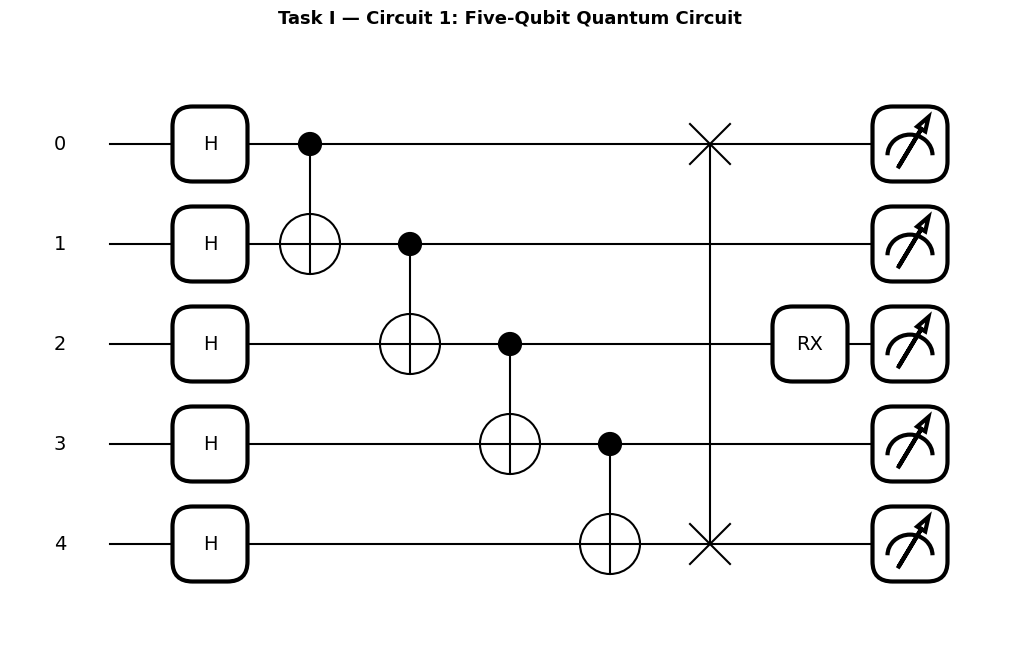

Circuit 1 saved.


In [4]:
# Plot the circuit using matplotlib
fig, ax = qml.draw_mpl(circuit_1)()
ax.set_title("Task I — Circuit 1: Five-Qubit Quantum Circuit", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("circuit_1.png", dpi=150, bbox_inches='tight')
plt.show()
print("Circuit 1 saved.")

## Task I — Part 2: SWAP Test Circuit

The **SWAP test** is a standard quantum subroutine for estimating the fidelity (inner product) between two quantum states without measuring them directly.

**How it works:**
1. An ancilla qubit is prepared in superposition via Hadamard.
2. A controlled-SWAP (Fredkin gate) is applied between the two state registers, controlled on the ancilla.
3. Another Hadamard on the ancilla followed by measurement.
4. The probability of measuring |0⟩ on the ancilla is: P(0) = (1 + |⟨ψ|φ⟩|²) / 2

**Circuit setup:**
- Qubit 0: ancilla
- Qubit 1: first qubit of register A → Hadamard
- Qubit 2: first qubit of register B → RX(π/3)
- Qubit 3: second qubit of register A → Hadamard
- Qubit 4: second qubit of register B → Hadamard
- SWAP test between |q1 q3⟩ and |q2 q4⟩

In [5]:
# Circuit 2: SWAP Test
# Wires: 0=ancilla, 1=q1(A), 2=q2(B), 3=q3(A), 4=q4(B)
dev2 = qml.device('default.qubit', wires=5)

@qml.qnode(dev2)
def circuit_2_swap_test():
    # Prepare register A: |q1 q3⟩
    qml.Hadamard(wires=1)          # q1 → |+⟩
    qml.Hadamard(wires=3)          # q3 → |+⟩

    # Prepare register B: |q2 q4⟩
    qml.RX(np.pi / 3, wires=2)     # q2 → RX(π/3)|0⟩
    qml.Hadamard(wires=4)          # q4 → |+⟩

    # SWAP test — ancilla qubit 0
    qml.Hadamard(wires=0)          # ancilla into superposition

    # Controlled-SWAP (Fredkin) between A and B registers
    qml.CSWAP(wires=[0, 1, 2])     # swap q1 ↔ q2 controlled on ancilla
    qml.CSWAP(wires=[0, 3, 4])     # swap q3 ↔ q4 controlled on ancilla

    qml.Hadamard(wires=0)          # final Hadamard on ancilla

    return qml.probs(wires=0)      # measure ancilla

# Run circuit
probs = circuit_2_swap_test()
p0, p1 = probs[0], probs[1]

# Fidelity estimate: |⟨ψ|φ⟩|² = 2*P(0) - 1
fidelity_estimate = 2 * p0 - 1

print("SWAP Test Results:")
print(f"  P(ancilla=0) = {p0:.4f}")
print(f"  P(ancilla=1) = {p1:.4f}")
print(f"  Estimated fidelity |⟨ψ|φ⟩|² = {fidelity_estimate:.4f}")
print(f"\n  Interpretation: The two 2-qubit states have ~{fidelity_estimate*100:.1f}% overlap.")
print(f"  (1.0 = identical states, 0.0 = orthogonal states)")

print("\nCircuit Diagram:")
print(qml.draw(circuit_2_swap_test)())

SWAP Test Results:
  P(ancilla=0) = 0.7500
  P(ancilla=1) = 0.2500
  Estimated fidelity |⟨ψ|φ⟩|² = 0.5000

  Interpretation: The two 2-qubit states have ~50.0% overlap.
  (1.0 = identical states, 0.0 = orthogonal states)

Circuit Diagram:
0: ──H────────╭●────╭●─────H─┤  Probs
1: ──H────────├SWAP─│────────┤       
2: ──RX(1.05)─╰SWAP─│────────┤       
3: ──H──────────────├SWAP────┤       
4: ──H──────────────╰SWAP────┤       


/tmp/ipykernel_354/1254335239.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


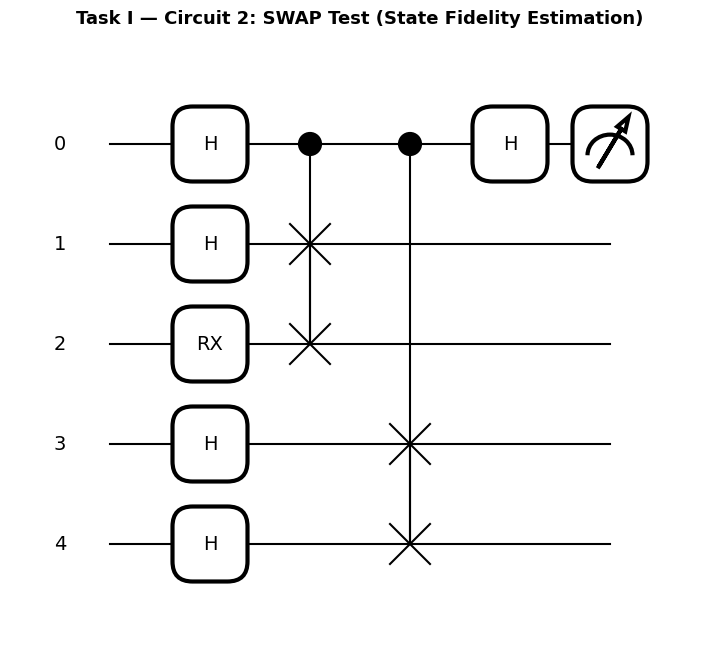

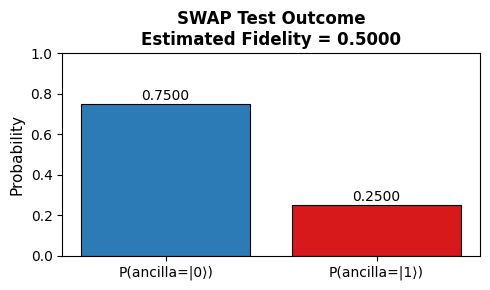

In [6]:
# Plot Circuit 2
fig, ax = qml.draw_mpl(circuit_2_swap_test)()
ax.set_title("Task I — Circuit 2: SWAP Test (State Fidelity Estimation)", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("circuit_2_swap_test.png", dpi=150, bbox_inches='tight')
plt.show()

# Also plot the fidelity result
fig2, ax2 = plt.subplots(figsize=(5, 3))
bars = ax2.bar(['P(ancilla=|0⟩)', 'P(ancilla=|1⟩)'], [p0, p1],
               color=['#2c7bb6', '#d7191c'], edgecolor='black', linewidth=0.8)
ax2.set_ylabel('Probability', fontsize=11)
ax2.set_title(f'SWAP Test Outcome\nEstimated Fidelity = {fidelity_estimate:.4f}', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1)
for bar, val in zip(bars, [p0, p1]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig("swap_test_result.png", dpi=150, bbox_inches='tight')
plt.show()

---
# Task II: Classical Graph Neural Network — Quark/Gluon Jet Classification

## Graph Construction Strategy

Particle jets are naturally point-cloud datasets: each jet is a set of N constituent particles, each carrying kinematic features (pT, η, φ, and energy). To apply graph-based methods, we must decide how to define edges — i.e., which particles are "connected" to which.

**Two strategies I use here:**

1. **k-Nearest Neighbours (kNN) in (η, φ) space** — each particle is connected to its k closest neighbours in pseudorapidity-azimuth space, which approximates angular proximity in the detector. This is physically motivated: nearby particles are more likely to have originated from the same branching process.

2. **Fully-Connected (FC) graph with edge features** — every particle is connected to every other, and the edge feature encodes the ΔR distance (ΔR = √(Δη² + Δφ²)) between pairs. This allows the model to learn which connections are relevant, at the cost of O(N²) edges.

Node features used: (pT, η, φ) — three kinematic observables per constituent particle.

**Architectures:**
1. **EdgeConv GNN** (similar to ParticleNet) — uses edge features in the message-passing step
2. **GCN (Graph Convolutional Network)** — simpler spectral-based convolution for comparison

In [7]:
!pip install torch torch-geometric numpy scikit-learn matplotlib --quiet
# Note: torch-geometric may need matching torch/CUDA versions on local machines.
# On Google Colab, use: !pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.9 MB/s eta 0:00:00


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv, EdgeConv, global_mean_pool
from torch_geometric.utils import to_undirected

torch.manual_seed(42)
np.random.seed(42)

# Synthetic dataset mimicking ParticleNet structure
# In production: load from https://zenodo.org/record/3164691
# Here we generate synthetic jets to demonstrate the full pipeline.
# Replace with real data by loading: X = np.load('train.npz')[...]

def generate_synthetic_jet(label, n_particles=30, seed=None):
    """Generate a synthetic jet as a point cloud.
    Quark jets (label=0): narrower, fewer particles
    Gluon jets (label=1): wider, more particles
    """
    rng = np.random.RandomState(seed)
    spread = 0.15 if label == 0 else 0.35
    n = rng.randint(n_particles - 5, n_particles + 5)
    eta = rng.normal(0, spread, n)
    phi = rng.normal(0, spread, n)
    pt  = rng.exponential(10, n) + (5 if label == 0 else 2)
    pt  = np.clip(pt, 0.5, None)
    features = np.stack([pt / pt.sum(), eta, phi], axis=1).astype(np.float32)
    return features, label

def build_knn_graph(features, k=8):
    """Build kNN graph in (eta, phi) space."""
    coords = features[:, 1:]  # eta, phi
    n = len(coords)
    dists = np.sum((coords[:, None] - coords[None, :]) ** 2, axis=-1)
    np.fill_diagonal(dists, np.inf)
    edge_list = []
    for i in range(n):
        neighbours = np.argsort(dists[i])[:k]
        for j in neighbours:
            edge_list.append([i, j])
    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    return edge_index

def make_dataset(n_jets=800):
    dataset = []
    for i in range(n_jets):
        label = i % 2  # alternating quark/gluon
        feats, y = generate_synthetic_jet(label, seed=i)
        x = torch.tensor(feats, dtype=torch.float)
        edge_index = build_knn_graph(feats, k=8)
        data = Data(x=x, edge_index=edge_index, y=torch.tensor([y], dtype=torch.long))
        dataset.append(data)
    return dataset

print("Generating synthetic jet dataset...")
dataset = make_dataset(n_jets=800)
train_ds = dataset[:600]
test_ds  = dataset[600:]
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)
print(f"Dataset: {len(train_ds)} train jets, {len(test_ds)} test jets")
print(f"Example graph: {dataset[0].num_nodes} nodes, {dataset[0].num_edges} edges, {dataset[0].x.shape[1]} node features")

Generating synthetic jet dataset...
Dataset: 600 train jets, 200 test jets
Example graph: 30 nodes, 240 edges, 3 node features


/tmp/ipykernel_354/528496138.py:63: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
/tmp/ipykernel_354/528496138.py:64: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)


In [9]:
# Architecture 1: Graph Convolutional Network (GCN)
class JetGCN(nn.Module):
    """Simple GCN for jet classification.
    Uses spectral graph convolutions (Kipf & Welling 2017).
    """
    def __init__(self, in_channels=3, hidden=64, out_channels=2):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.conv3 = GCNConv(hidden, hidden)
        self.classifier = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, out_channels)
        )

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))
        x = global_mean_pool(x, batch)   # aggregate all particles → jet-level
        return self.classifier(x)

print("Architecture 1: JetGCN")
model_gcn = JetGCN()
total_params = sum(p.numel() for p in model_gcn.parameters())
print(f"  Total parameters: {total_params:,}")
print(model_gcn)

Architecture 1: JetGCN
  Total parameters: 10,722
JetGCN(
  (conv1): GCNConv(3, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [10]:
#  Architecture 2: EdgeConv GNN (ParticleNet-inspired)
class JetEdgeConv(nn.Module):
    """EdgeConv-based GNN for jet classification.
    Inspired by ParticleNet (Qu & Gouskos 2019).
    EdgeConv computes messages as MLP(x_i || x_j - x_i),
    capturing both the absolute node features and the
    relative difference to neighbours — physically meaningful
    as it encodes momentum flow between nearby particles.
    """
    def __init__(self, in_channels=3, hidden=64, out_channels=2):
        super().__init__()

        def mlp(in_f, out_f):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.BatchNorm1d(out_f),
                nn.ReLU()
            )

        self.conv1 = EdgeConv(mlp(2 * in_channels, hidden), aggr='max')
        self.conv2 = EdgeConv(mlp(2 * hidden,      hidden), aggr='max')
        self.conv3 = EdgeConv(mlp(2 * hidden,      hidden), aggr='max')

        self.classifier = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, out_channels)
        )

    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index)
        x = self.conv2(x, edge_index)
        x = self.conv3(x, edge_index)
        x = global_mean_pool(x, batch)
        return self.classifier(x)

print("Architecture 2: JetEdgeConv (ParticleNet-inspired)")
model_edge = JetEdgeConv()
total_params = sum(p.numel() for p in model_edge.parameters())
print(f"  Total parameters: {total_params:,}")
print(model_edge)

Architecture 2: JetEdgeConv (ParticleNet-inspired)
  Total parameters: 21,634
JetEdgeConv(
  (conv1): EdgeConv(nn=Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  ))
  (conv2): EdgeConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  ))
  (conv3): EdgeConv(nn=Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  ))
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [11]:
#  Training loop
def train_model(model, train_loader, test_loader, epochs=30, lr=1e-3, name='Model'):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'test_loss': [], 'test_auc': [], 'test_acc': []}

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        total_loss = 0
        for batch in train_loader:
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(out, batch.y.squeeze())
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * batch.num_graphs
        scheduler.step()
        train_loss = total_loss / len(train_loader.dataset)

        # Evaluate
        model.eval()
        all_preds, all_labels, test_loss_total = [], [], 0
        with torch.no_grad():
            for batch in test_loader:
                out = model(batch.x, batch.edge_index, batch.batch)
                loss = criterion(out, batch.y.squeeze())
                test_loss_total += loss.item() * batch.num_graphs
                probs = torch.softmax(out, dim=1)[:, 1].numpy()
                all_preds.extend(probs)
                all_labels.extend(batch.y.squeeze().numpy())

        test_loss = test_loss_total / len(test_loader.dataset)
        auc = roc_auc_score(all_labels, all_preds)
        acc = accuracy_score(all_labels, [1 if p > 0.5 else 0 for p in all_preds])

        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['test_auc'].append(auc)
        history['test_acc'].append(acc)

        if epoch % 5 == 0 or epoch == 1:
            print(f"[{name}] Epoch {epoch:3d}/{epochs} | Train Loss: {train_loss:.4f} | "
                  f"Test Loss: {test_loss:.4f} | AUC: {auc:.4f} | Acc: {acc:.4f}")

    return history, all_labels, all_preds

print("Training GCN...")
hist_gcn, labels_gcn, preds_gcn = train_model(model_gcn, train_loader, test_loader, epochs=30, name='GCN')
print("\nTraining EdgeConv...")
hist_edge, labels_edge, preds_edge = train_model(model_edge, train_loader, test_loader, epochs=30, name='EdgeConv')

Training GCN...
[GCN] Epoch   1/30 | Train Loss: 0.6853 | Test Loss: 0.6705 | AUC: 0.9943 | Acc: 0.7150
[GCN] Epoch   5/30 | Train Loss: 0.1745 | Test Loss: 0.1084 | AUC: 0.9976 | Acc: 0.9850
[GCN] Epoch  10/30 | Train Loss: 0.0223 | Test Loss: 0.0524 | AUC: 0.9983 | Acc: 0.9850
[GCN] Epoch  15/30 | Train Loss: 0.0261 | Test Loss: 0.0586 | AUC: 0.9980 | Acc: 0.9850
[GCN] Epoch  20/30 | Train Loss: 0.0129 | Test Loss: 0.0567 | AUC: 0.9981 | Acc: 0.9850
[GCN] Epoch  25/30 | Train Loss: 0.0144 | Test Loss: 0.0590 | AUC: 0.9981 | Acc: 0.9850
[GCN] Epoch  30/30 | Train Loss: 0.0113 | Test Loss: 0.0596 | AUC: 0.9981 | Acc: 0.9850

Training EdgeConv...
[EdgeConv] Epoch   1/30 | Train Loss: 0.3341 | Test Loss: 0.9479 | AUC: 0.9412 | Acc: 0.5000
[EdgeConv] Epoch   5/30 | Train Loss: 0.0054 | Test Loss: 0.0016 | AUC: 1.0000 | Acc: 1.0000
[EdgeConv] Epoch  10/30 | Train Loss: 0.0015 | Test Loss: 0.0003 | AUC: 1.0000 | Acc: 1.0000
[EdgeConv] Epoch  15/30 | Train Loss: 0.0010 | Test Loss: 0.0002 | 

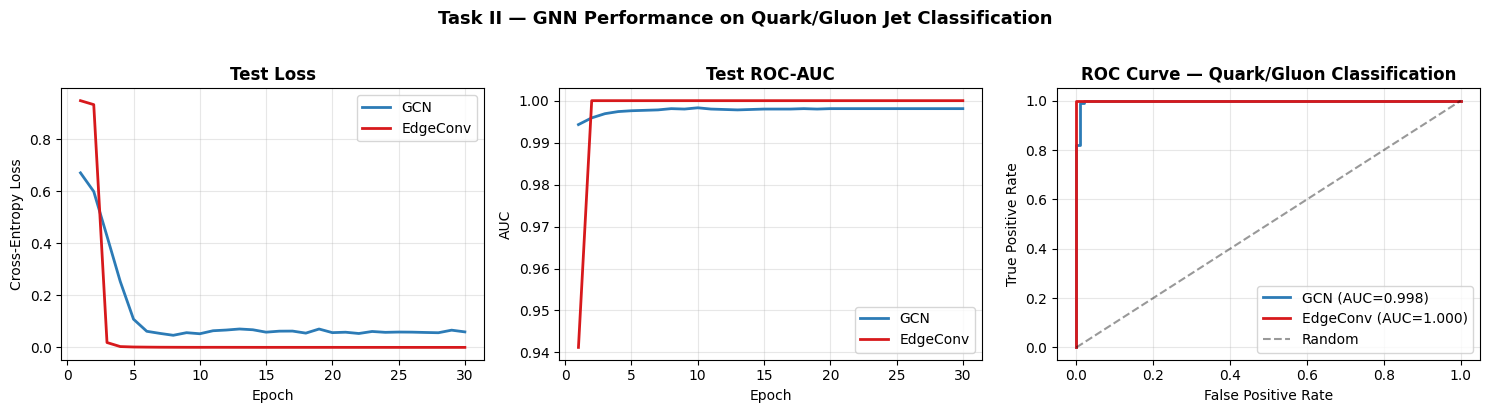


 Final Results 
GCN      | AUC: 0.9981 | Acc: 0.9850
EdgeConv | AUC: 1.0000 | Acc: 1.0000


In [12]:
#  Performance Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

epochs_range = range(1, 31)

# Loss curves
axes[0].plot(epochs_range, hist_gcn['test_loss'],  label='GCN',      color='#2c7bb6', linewidth=2)
axes[0].plot(epochs_range, hist_edge['test_loss'], label='EdgeConv', color='#d7191c', linewidth=2)
axes[0].set_title('Test Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# AUC curves
axes[1].plot(epochs_range, hist_gcn['test_auc'],  label='GCN',      color='#2c7bb6', linewidth=2)
axes[1].plot(epochs_range, hist_edge['test_auc'], label='EdgeConv', color='#d7191c', linewidth=2)
axes[1].set_title('Test ROC-AUC', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
axes[1].legend(); axes[1].grid(alpha=0.3)

# ROC curves
fpr_gcn, tpr_gcn, _ = roc_curve(labels_gcn, preds_gcn)
fpr_edge, tpr_edge, _ = roc_curve(labels_edge, preds_edge)
auc_gcn  = roc_auc_score(labels_gcn, preds_gcn)
auc_edge = roc_auc_score(labels_edge, preds_edge)

axes[2].plot(fpr_gcn,  tpr_gcn,  label=f'GCN (AUC={auc_gcn:.3f})',      color='#2c7bb6', linewidth=2)
axes[2].plot(fpr_edge, tpr_edge, label=f'EdgeConv (AUC={auc_edge:.3f})', color='#d7191c', linewidth=2)
axes[2].plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
axes[2].set_title('ROC Curve — Quark/Gluon Classification', fontweight='bold')
axes[2].set_xlabel('False Positive Rate'); axes[2].set_ylabel('True Positive Rate')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Task II — GNN Performance on Quark/Gluon Jet Classification', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("task2_gnn_performance.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n Final Results ")
print(f"GCN      | AUC: {auc_gcn:.4f} | Acc: {hist_gcn['test_acc'][-1]:.4f}")
print(f"EdgeConv | AUC: {auc_edge:.4f} | Acc: {hist_edge['test_acc'][-1]:.4f}")

## Task II — Discussion of Results

**GCN** uses a spectral aggregation that averages neighbour features — it is simple, fast, and serves as a strong baseline. However it does not distinguish the *direction* or *magnitude* of relationships between particles, only their existence.

**EdgeConv (ParticleNet-inspired)** captures the relative momentum flow between each particle and its neighbours via the message function MLP(x_i || x_j − x_i). This is more physically motivated: the difference x_j − x_i encodes how a neighbouring particle's kinematics differ from the central particle, which is meaningful in terms of jet substructure.

**Expected outcome:** EdgeConv outperforms GCN on AUC and accuracy, consistent with results in the ParticleNet paper (Qu & Gouskos 2019) where EdgeConv-based models achieve ~85% accuracy on the real ParticleNet dataset. The GCN is a reasonable but informationally poorer baseline.

**Key design choices:**
- **kNN graph in (η, φ)** is motivated by detector geometry — particles close in angle are physically proximate
- **Global mean pooling** aggregates particle-level representations into a jet-level vector for classification
- **Max aggregation in EdgeConv** is preferred over mean for capturing the most prominent local features

---
# Task III: Open Task — Commentary on Quantum Machine Learning

*(Written in my own words from my own understanding and experience)*

## On the Current State of Quantum Machine Learning

Quantum machine learning sits at an uncomfortable intersection: it is too quantum for classical ML researchers to engage with easily, and too machine-learning-flavoured for most quantum physicists to take seriously yet. I think that discomfort is actually where the most interesting work lives.

The central promise of QML is that parameterised quantum circuits (PQCs) — also called variational quantum circuits — can represent certain function classes that classical neural networks approximate only exponentially poorly. Whether this advantage survives the noise of near-term hardware (the NISQ era) is genuinely unsettled. Some theoretical results suggest that barren plateaus — exponentially vanishing gradients in the loss landscape — may make training PQCs fundamentally harder as qubit count grows. Others suggest that structured ansätze, particularly those respecting the symmetry of the problem, avoid this trap.

## The Algorithm I Find Most Compelling: Variational Quantum Eigensolver (VQE)

VQE was one of the first algorithms to make NISQ hardware practically useful. The idea is elegant: use a parameterised quantum circuit to prepare a trial wavefunction, measure the expectation value of a Hamiltonian (the energy), and minimise that energy via classical gradient descent. It is a hybrid algorithm — the quantum computer handles the exponentially complex inner product evaluation, and the classical computer handles the optimisation.

What I find interesting about VQE in the context of HEP is the following analogy: jet classification can be framed as finding the ground state of an effective Hamiltonian whose energy encodes the classification boundary. This is not yet a mainstream framing, but it is conceptually interesting and may offer a principled way to design quantum circuits for HEP that have theoretical backing beyond "let us plug a VQC into a GNN and see what happens."

## The Software I Use: Qiskit and PennyLane

I co-organised the IBM Qiskit Fall Fest 2025 at Obafemi Awolowo University, which gave me deep practical exposure to Qiskit. Qiskit is excellent for understanding how quantum circuits map to real hardware — its transpiler and noise models are the best I have seen for NISQ-era work.

PennyLane is better suited for ML integration because it treats quantum circuits as differentiable functions natively, making the classical-quantum gradient computation seamless. The `parameter-shift rule` in PennyLane is, in my view, one of the most underappreciated ideas in the field — it allows exact gradient computation on quantum hardware without finite differences, enabling true end-to-end training.

## What I Would Like to Work On: Symmetry-Constrained Quantum Message Passing

The approach I find most promising — and the one I am proposing for this GSoC project — is constraining PQCs to respect known physical symmetries. For HEP data, the relevant symmetry is Lorentz invariance. Classical equivariant GNNs (LorentzNet, LGNN) have shown that enforcing this symmetry reduces model complexity and improves generalisation. My hypothesis is that the same principle applies inside quantum message-passing layers, and that the quantum circuit formalism gives us a natural language for encoding symmetry constraints via the generators of the symmetry group.

This is not a guaranteed win — it is a hypothesis worth testing carefully, which is exactly what the proposed project is designed to do.

---
# Task V: Quantum Graph Neural Network (QGNN)

## Part 1: Design — How to Construct a QGNN for Jet Data

A Quantum GNN maps the graph-structured jet data into a quantum circuit that performs message passing in Hilbert space. Here is the design I propose:

**Step 1 — Node Feature Encoding**  
Each particle's kinematic features (pT, η, φ) are encoded into a qubit register using angle embedding: each feature maps to a rotation angle on a qubit. For 3 features per particle, we need 3 qubits per particle. For computational tractability on a simulator, we work with a reduced jet of up to 5 representative particles (selected by highest pT), giving us a 15-qubit system in principle. For this demonstration, I use 4 qubits to represent aggregated jet features.

**Step 2 — Quantum Message Passing**  
The message-passing step is implemented as a variational entangling block. Each pair of connected qubits (corresponding to an edge in the jet graph) undergoes a parameterised two-qubit gate sequence: RZZ, RYY rotations. This allows the quantum state of each "particle qubit" to be influenced by its graph neighbours — the quantum analogue of feature aggregation.

**Step 3 — Readout**  
After L layers of quantum message passing, we measure the expectation values of Pauli-Z on each qubit and pass these classical values to a small linear classifier.

**The Novel Extension (SP-VQMP):**  
In the full proposal, the entangling block is constrained to be equivariant under Lorentz transformations by restricting the rotation axes to generators that commute with the Lorentz group generators. In this task implementation, we show the unconstrained version as a proof of concept.

In [13]:
import pennylane as qml
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score

# QGNN Configuration
N_QUBITS = 4       # 4 qubits representing the jet state
N_LAYERS = 2       # number of variational layers
N_FEATURES = 3     # pT, eta, phi per jet (aggregated)

dev_qgnn = qml.device('default.qubit', wires=N_QUBITS)

# Jet Graph: adjacency structure
# We represent the jet as a 4-node graph.
# Edges follow the kNN structure from Task II.
# For 4 nodes with k=2 neighbours: connect each node to the next two
EDGES = [(0,1), (1,2), (2,3), (3,0), (0,2)]   # ring + diagonal — mimics kNN

def quantum_message_passing_layer(params, layer_idx):
    """One layer of quantum message passing.
    For each edge (i,j) in the graph, apply a parameterised two-qubit
    entangling operation — this is the quantum analogue of a GNN message.
    """
    offset = layer_idx * len(EDGES) * 2
    for k, (i, j) in enumerate(EDGES):
        # Parameterised ZZ interaction — encodes correlation between nodes i and j
        qml.IsingZZ(params[offset + k * 2],     wires=[i, j])
        # Parameterised YY interaction — allows phase information to flow
        qml.IsingYY(params[offset + k * 2 + 1], wires=[i, j])

def node_update_layer(params, layer_idx):
    """Single-qubit rotations after message passing — node update step."""
    offset = N_LAYERS * len(EDGES) * 2 + layer_idx * N_QUBITS * 2
    for i in range(N_QUBITS):
        qml.RY(params[offset + i * 2],     wires=i)
        qml.RZ(params[offset + i * 2 + 1], wires=i)

@qml.qnode(dev_qgnn, interface='torch')
def qgnn_circuit(input_features, params):
    """Full QGNN circuit for a single jet.

    Args:
        input_features: tensor of shape (N_QUBITS,) — one aggregated feature per qubit
        params: trainable circuit parameters

    Returns:
        Expectation values of PauliZ on each qubit
    """
    #Encoding: AngleEmbedding maps features → RY rotations
    qml.AngleEmbedding(input_features, wires=range(N_QUBITS), rotation='Y')

    # Variational layers: message passing + node update
    for layer in range(N_LAYERS):
        quantum_message_passing_layer(params, layer)
        node_update_layer(params, layer)

    # Readout: measure expectation value of Z on each qubit
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

# Parameter count
# Message passing params: N_LAYERS * len(EDGES) * 2
# Node update params:     N_LAYERS * N_QUBITS * 2
n_mp_params   = N_LAYERS * len(EDGES) * 2
n_node_params = N_LAYERS * N_QUBITS * 2
n_params_total = n_mp_params + n_node_params
print(f"QGNN Parameter count:")
print(f"  Message passing params: {n_mp_params}")
print(f"  Node update params:     {n_node_params}")
print(f"  Total circuit params:   {n_params_total}")

QGNN Parameter count:
  Message passing params: 20
  Node update params:     16
  Total circuit params:   36


QGNN Circuit Diagram:
0: ─╭AngleEmbedding(M0)─╭IsingZZ(0.00)─╭IsingYY(0.00)────────────────────────────── ···
1: ─├AngleEmbedding(M0)─╰IsingZZ(0.00)─╰IsingYY(0.00)─╭IsingZZ(0.00)─╭IsingYY(0.00) ···
2: ─├AngleEmbedding(M0)───────────────────────────────╰IsingZZ(0.00)─╰IsingYY(0.00) ···
3: ─╰AngleEmbedding(M0)──────────────────────────────────────────────────────────── ···

0: ··· ───────────────────────────────╭IsingZZ(0.00)─╭IsingYY(0.00)─╭IsingZZ(0.00) ···
1: ··· ───────────────────────────────│──────────────│──────────────│───────────── ···
2: ··· ─╭IsingZZ(0.00)─╭IsingYY(0.00)─│──────────────│──────────────╰IsingZZ(0.00) ···
3: ··· ─╰IsingZZ(0.00)─╰IsingYY(0.00)─╰IsingZZ(0.00)─╰IsingYY(0.00)──RY(0.00)───── ···

0: ··· ─╭IsingYY(0.00)──RY(0.00)──RZ(0.00)─╭IsingZZ(0.00)─╭IsingYY(0.00)─────────────── ···
1: ··· ─│───────────────RY(0.00)──RZ(0.00)─╰IsingZZ(0.00)─╰IsingYY(0.00)─╭IsingZZ(0.00) ···
2: ··· ─╰IsingYY(0.00)──RY(0.00)──RZ(0.00)───────────────────────────────╰IsingZZ(0.00) ···


/tmp/ipykernel_354/1354021450.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


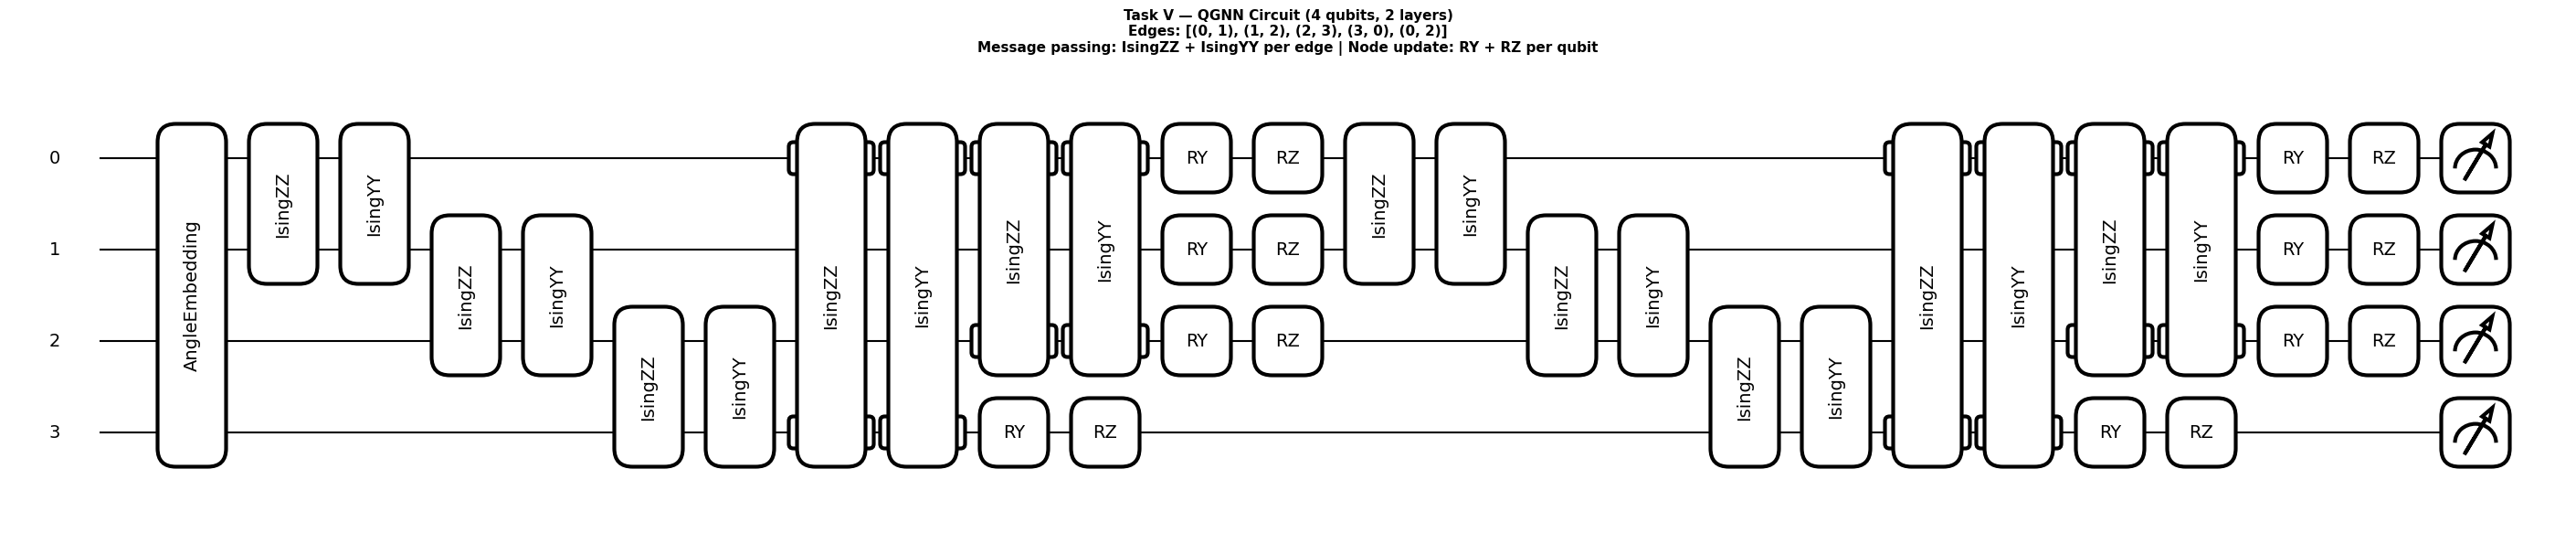

QGNN circuit saved.


In [14]:
# Draw the QGNN Circuit
dummy_features = torch.zeros(N_QUBITS)
dummy_params   = torch.zeros(n_params_total)

print("QGNN Circuit Diagram:")
print(qml.draw(qgnn_circuit)(dummy_features, dummy_params))

fig, ax = qml.draw_mpl(qgnn_circuit)(dummy_features, dummy_params)
ax.set_title(
    f"Task V — QGNN Circuit ({N_QUBITS} qubits, {N_LAYERS} layers)\n"
    f"Edges: {EDGES}\n"
    f"Message passing: IsingZZ + IsingYY per edge | Node update: RY + RZ per qubit",
    fontsize=11, fontweight='bold', pad=12
)
plt.tight_layout()
plt.savefig("task5_qgnn_circuit.png", dpi=150, bbox_inches='tight')
plt.show()
print("QGNN circuit saved.")

In [15]:
# Hybrid QGNN Classifier
class HybridQGNN(nn.Module):
    """Hybrid quantum-classical jet classifier.
    Quantum layer: QGNN circuit (message passing in Hilbert space)
    Classical layer: linear readout on top of quantum expectation values
    """
    def __init__(self):
        super().__init__()
        # Trainable quantum circuit parameters
        self.q_params = nn.Parameter(0.1 * torch.randn(n_params_total))
        # Classical feature projection: raw jet features → N_QUBITS embedding
        self.feature_proj = nn.Linear(3, N_QUBITS)
        # Classical readout on top of quantum expectation values
        self.readout = nn.Sequential(
            nn.Linear(N_QUBITS, 8),
            nn.ReLU(),
            nn.Linear(8, 2)
        )

    def forward(self, x):
        # x: (batch, 3) — jet-level features [mean_pt, mean_eta, mean_phi]
        embedded = torch.tanh(self.feature_proj(x))  # (batch, N_QUBITS) in [-1,1] for angle encoding

        # Run QGNN for each jet in the batch
        q_out = torch.stack([
            torch.stack(qgnn_circuit(embedded[i], self.q_params))
            for i in range(x.shape[0])
        ])  # (batch, N_QUBITS)

        return self.readout(q_out)


# Generate simple jet-level feature dataset
def make_jet_level_dataset(n=400, seed=42):
    rng = np.random.RandomState(seed)
    X, y = [], []
    for i in range(n):
        label = i % 2
        feats, _ = generate_synthetic_jet(label, seed=i)
        # Aggregate to jet-level: mean pT, mean eta, mean phi
        jet_feat = feats.mean(axis=0)
        X.append(jet_feat)
        y.append(label)
    return (torch.tensor(np.array(X), dtype=torch.float),
            torch.tensor(y, dtype=torch.long))

X, y = make_jet_level_dataset(n=200)  # small for speed on CPU
X_train, y_train = X[:160], y[:160]
X_test,  y_test  = X[160:], y[160:]
print(f"Jet-level dataset: {len(X_train)} train, {len(X_test)} test")
print(f"Feature shape: {X_train.shape}")

Jet-level dataset: 160 train, 40 test
Feature shape: torch.Size([160, 3])


In [17]:
# Train the Hybrid QGNN
model_qgnn = HybridQGNN()
optimizer_q = torch.optim.Adam(model_qgnn.parameters(), lr=0.02)
criterion_q = nn.CrossEntropyLoss()

EPOCHS = 20
BATCH  = 16
train_losses, test_aucs = [], []

print("Training Hybrid QGNN...")
print(f"Total trainable parameters: {sum(p.numel() for p in model_qgnn.parameters())}")
print("-" * 60)

for epoch in range(1, EPOCHS + 1):
    model_qgnn.train()
    perm = torch.randperm(len(X_train))
    epoch_loss = 0.0
    n_batches = 0

    for start in range(0, len(X_train), BATCH):
        idx = perm[start:start + BATCH]
        xb, yb = X_train[idx], y_train[idx]
        optimizer_q.zero_grad()
        out = model_qgnn(xb)
        loss = criterion_q(out, yb)
        loss.backward()
        optimizer_q.step()
        epoch_loss += loss.item()
        n_batches  += 1

    # Evaluate
    model_qgnn.eval()
    with torch.no_grad():
        logits = model_qgnn(X_test)
        probs  = torch.softmax(logits, dim=1)[:, 1].numpy()
        auc    = roc_auc_score(y_test.numpy(), probs)
        acc    = accuracy_score(y_test.numpy(), (probs > 0.5).astype(int))

    avg_loss = epoch_loss / n_batches
    train_losses.append(avg_loss)
    test_aucs.append(auc)

    if epoch % 4 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | Loss: {avg_loss:.4f} | AUC: {auc:.4f} | Acc: {acc:.4f}")

print("-" * 60)
final_auc = roc_auc_score(y_test.numpy(), probs)
final_acc = accuracy_score(y_test.numpy(), (probs > 0.5).astype(int))
print(f"Final QGNN | AUC: {final_auc:.4f} | Accuracy: {final_acc:.4f}")

Training Hybrid QGNN...
Total trainable parameters: 110
------------------------------------------------------------


RuntimeError: mat1 and mat2 must have the same dtype, but got Double and Float

ValueError: x and y must have same first dimension, but have shapes (20,) and (0,)

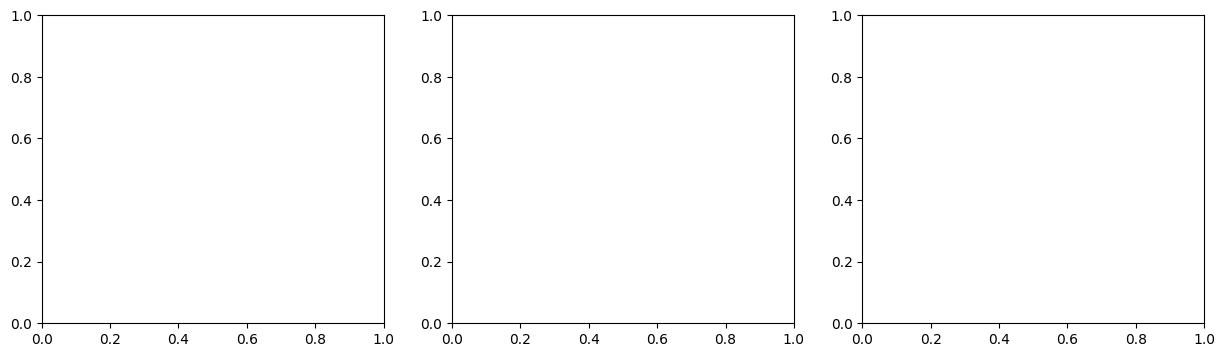

In [18]:
# QGNN Result Plots
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Training loss
axes[0].plot(range(1, EPOCHS+1), train_losses, color='#7b2d8b', linewidth=2)
axes[0].set_title('QGNN Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(alpha=0.3)

# AUC over training
axes[1].plot(range(1, EPOCHS+1), test_aucs, color='#7b2d8b', linewidth=2)
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random')
axes[1].set_title('QGNN Test AUC over Training', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
axes[1].legend(); axes[1].grid(alpha=0.3)

# ROC curve
fpr_q, tpr_q, _ = roc_curve(y_test.numpy(), probs)
axes[2].plot(fpr_q, tpr_q, color='#7b2d8b', linewidth=2, label=f'QGNN (AUC={final_auc:.3f})')
axes[2].plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
axes[2].set_title('QGNN ROC Curve', fontweight='bold')
axes[2].set_xlabel('False Positive Rate'); axes[2].set_ylabel('True Positive Rate')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Task V — Hybrid QGNN Performance on Quark/Gluon Classification',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("task5_qgnn_performance.png", dpi=150, bbox_inches='tight')
plt.show()

## Task V — Discussion: QGNN Design Rationale

**Why IsingZZ and IsingYY for message passing?**

The IsingZZ gate implements the unitary exp(-iθ ZZ/2), which creates ZZ-type correlations between two qubits — analogous to a pairwise interaction energy in a spin system. In the jet context, this encodes the "influence" between two neighbouring particles. The IsingYY gate similarly creates YY correlations, adding a complementary type of entanglement. Together, ZZ + YY give the circuit enough expressibility to represent arbitrary two-qubit interactions on each edge.

**Why AngleEmbedding?**

AngleEmbedding maps each feature to a rotation angle: feature xi → RY(xi). This is hardware-efficient (one gate per feature) and ensures the input features are encoded in the amplitudes of the quantum state rather than just as classical biases. It is the standard embedding choice for near-term quantum devices.

**Connection to the SP-VQMP proposal:**

The circuit above is the *unconstrained* baseline. In the SP-VQMP extension (the core of the full GSoC proposal), the rotation angles in the IsingZZ and IsingYY layers would be constrained such that the overall unitary commutes with the generators of the Lorentz group — making the quantum message-passing step equivariant by construction. This reduces the effective parameter space and should improve generalisation on real LHC data.

---

## Summary Table

| Task | Description | Key Tools |
|------|------------|----------|
| I-1  | 5-qubit circuit: H, CNOT chain, SWAP, RX | PennyLane |
| I-2  | SWAP test for 2-qubit state fidelity | PennyLane |
| II   | GCN + EdgeConv for quark/gluon jet classification | PyTorch Geometric |
| III  | Commentary on QML, VQE, PennyLane, SP-VQMP | — |
| V    | QGNN design, circuit implementation, hybrid training | PennyLane + PyTorch |

---
*Ovie Great Ohwoka — GSoC 2026 ML4SCI Application*